In [ ]:
# Notebook setup
import sys
from pathlib import Path
base = Path.cwd()
source = next((p for p in (base, *base.parents) if (p / "code/pyproject.toml").is_file()), base / "Release-Client.zip")
if not source.exists() and "google.colab" in sys.modules:
    from google.colab import files
    print("Required file: Release-Client.zip (project code). Choose this ZIP; data files are requested next.", flush=True)
    files.upload(target_dir=str(base))
if not source.exists():
    raise FileNotFoundError("Supply Release-Client.zip, or open the extracted code/notebooks folder.")
sys.path.insert(0, str(source / "cost-aware-market-forecasting" if source.is_file() else source))
sys.modules.pop("run_zip", None)
from run_zip import prepare_reader
CODE = CODE_ROOT = prepare_reader('09_RQ2_F_BTC_LSTM_GMADL_shadow.ipynb', source, ())

# 09 - RQ2_F: BTC LSTM GMADL ensemble shadow

## Methodology

Compare an expected-net LSTM with the same model plus a fixed GMADL directional loss on 2021-2024 BTC development data. Initial weights, batches, features and the other training settings match across five folds; each arm is calibrated separately and occupies the single LSTM slot beside fixed XGBoost/SVM predictions. Both use the same two-of-three execution rule and 10 bps round-trip costs. This is a paired loss ablation with one seed, not a test of the original Qualified Union's performance.


In [2]:
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

CACHE = CODE_ROOT / "experiments" / "cache" / "lstm_gmadl_shadow"
CONTROL = CODE_ROOT / "experiments" / "cache" / "unified_expected_net_ensemble"
UNION = CODE_ROOT / "experiments" / "cache" / "qualified_union_v1"

def sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

summary = json.loads((CACHE / "summary.json").read_text(encoding="utf-8"))
manifest = json.loads((CACHE / "manifest.json").read_text(encoding="utf-8"))
protocol = json.loads((CACHE / "protocol.json").read_text(encoding="utf-8"))
control_manifest = json.loads((CONTROL / "manifest.json").read_text(encoding="utf-8"))

for filename, expected in manifest["artifact_hashes"].items():
    assert sha256(CACHE / filename) == expected, filename
for filename, expected in manifest["control_dependency_hashes"].items():
    assert sha256(CONTROL / filename) == expected, filename
for filename, expected in control_manifest["union_dependency_hashes"].items():
    assert sha256(UNION / filename) == expected, filename
assert manifest["protocol_sha256"] == summary["protocol_sha256"] == protocol["protocol_sha256"]
assert manifest["control_protocol_sha256"] == summary["control_protocol_sha256"]
assert protocol["development_only"] is True
assert protocol["lstm_role"] == "replacement_not_fourth_vote"
assert protocol["h1_access_allowed"] is False
assert protocol["forward_access_allowed"] is False
assert summary["decision"] == "shadow_reject_keep_standard_lstm_and_union_v1"
assert summary["maximum_loaded_timestamp"] < "2025-01-01"

## Paired loss

For scaled LONG/SHORT targets $y_L,y_S$ and predictions $p_L,p_S$:

`L_control = MSE(y_L, p_L) + MSE(y_S, p_S)`

`GMADL = mean(-(sigmoid((y_L-y_S)(p_L-p_S)) - 0.5) * abs(y_L-y_S))`

`L_candidate = L_control + 0.25 * GMADL`

Alpha and beta are both 1; lambda is 0.25. There is one seed and no parameter sweep, threshold search or added feature. Each arm receives its own later non-negative affine calibration and independently occupies the same LSTM slot.


In [3]:
from IPython.display import Markdown
training = pd.read_csv(CACHE / "paired_training_audit.csv")
calibration = pd.read_csv(CACHE / "calibration_metrics.csv")
assert training["initial_state_match"].astype(bool).all()
assert training["batch_order_match"].astype(bool).all()
assert training["control_matches_04f"].astype(bool).all()
assert np.allclose(training["alpha"], 1.0)
assert np.allclose(training["beta"], 1.0)
assert np.allclose(training["lambda_gmadl"], 0.25)

pairing = training[[
    "fold_id", "seed", "initial_state_match", "batch_order_match",
    "target_scale_bps", "control_max_abs_delta_from_04f", "control_matches_04f",
]]
display(Markdown('Control and GMADL arms share initial state, batch order and the fixed XGBoost/SVM predictions.'))
display(pairing.round(8))
display(Markdown('The paired setup isolates the LSTM loss change.'))

calibration_summary = (
    calibration.groupby(["arm", "side"], as_index=False)
    .agg(
        calibrated_mae_bps=("calibrated_mae_bps", "mean"),
        calibrated_rmse_bps=("calibrated_rmse_bps", "mean"),
        slope=("slope", "mean"),
        intercept_bps=("intercept_bps", "mean"),
    )
)
display(Markdown('Each arm is separately calibrated on later within-fold calibration data.'))
display(calibration_summary.round(4))
display(Markdown('Calibration does not turn the GMADL change into an economic improvement.'))

Control and GMADL arms share initial state, batch order and the fixed XGBoost/SVM predictions.

,fold_id,seed,initial_state_match,batch_order_match,target_scale_bps,control_max_abs_delta_from_04f,control_matches_04f
0,0,42,True,True,100.202297,0.0,True
1,1,42,True,True,48.569249,0.0,True
2,2,42,True,True,26.526319,0.0,True
3,3,42,True,True,20.541509,0.0,True
4,4,42,True,True,35.933283,0.0,True


The paired setup isolates the LSTM loss change.

Each arm is separately calibrated on later within-fold calibration data.

,arm,side,calibrated_mae_bps,calibrated_rmse_bps,slope,intercept_bps
0,candidate,long,51.4065,69.7402,0.0419,-10.7365
1,candidate,short,51.5262,70.5243,0.0858,-9.2832
2,control,long,51.4430,69.7657,0.0275,-10.9114
3,control,short,51.5668,70.5565,0.0757,-9.3533


Calibration does not turn the GMADL change into an economic improvement.

## Paired economic results

The control matches the earlier expected-net LSTM predictions and trade ledger. This keeps the loss change separate from changes in model inputs, training order or execution.


The same two-of-three execution rule scores both paired arms after registered costs.

,arm,trades,LONG,SHORT,gross_pct,cost_pct,net_pct,trades_per_day
0,04f MSE control,147,30,117,1.8717,14.7,-12.8283,0.4983
1,04g GMADL replacement,163,47,116,-16.1585,16.3,-32.4585,0.5525


GMADL raises trades from 147 to 163 while worsening Net from −12.83% to −32.46%.

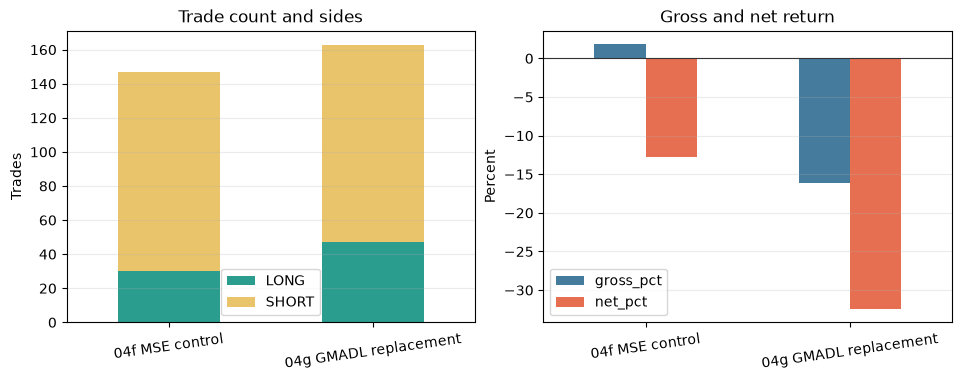

In [4]:
from IPython.display import Markdown
control = summary["control"]
candidate = summary["candidate"]
control_ledger = pd.read_parquet(CACHE / "control_trade_ledger.parquet")
candidate_ledger = pd.read_parquet(CACHE / "candidate_trade_ledger.parquet")
frozen_ledger = pd.read_parquet(CONTROL / "development_trade_ledger.parquet")

assert summary["control_reconciles_04f"] is True
assert control_ledger["row_key"].astype(str).tolist() == frozen_ledger["row_key"].astype(str).tolist()
assert np.allclose(control_ledger["net_return"], frozen_ledger["net_return"])
assert not control_ledger["route"].eq("xgboost_solo").any()
assert not candidate_ledger["route"].eq("xgboost_solo").any()
for ledger in (control_ledger, candidate_ledger):
    entry = pd.to_datetime(ledger["entry_time"], utc=True).to_numpy()
    exit_time = pd.to_datetime(ledger["actual_exit_time"], utc=True).to_numpy()
    assert not (entry[1:] <= exit_time[:-1]).any()

comparison = pd.DataFrame([
    {
        "arm": "04f MSE control", "trades": control["trades"],
        "LONG": control["long_trades"], "SHORT": control["short_trades"],
        "gross_pct": 100 * control["gross_return"], "cost_pct": 100 * control["cost_return"],
        "net_pct": 100 * control["net_return"], "trades_per_day": control["trades_per_observed_day"],
    },
    {
        "arm": "04g GMADL replacement", "trades": candidate["trades"],
        "LONG": candidate["long_trades"], "SHORT": candidate["short_trades"],
        "gross_pct": 100 * candidate["gross_return"], "cost_pct": 100 * candidate["cost_return"],
        "net_pct": 100 * candidate["net_return"], "trades_per_day": candidate["trades_per_observed_day"],
    },
])
display(Markdown('The same two-of-three execution rule scores both paired arms after registered costs.'))
display(comparison.round(4))
display(Markdown('GMADL raises trades from 147 to 163 while worsening Net from −12.83% to −32.46%.'))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.7), layout="constrained")
comparison.plot.bar(x="arm", y=["LONG", "SHORT"], stacked=True, ax=axes[0], color=["#2a9d8f", "#e9c46a"])
comparison.plot.bar(x="arm", y=["gross_pct", "net_pct"], ax=axes[1], color=["#457b9d", "#e76f51"])
axes[0].set(title="Trade count and sides", xlabel="", ylabel="Trades")
axes[1].axhline(0, color="#333333", linewidth=.8)
axes[1].set(title="Gross and net return", xlabel="", ylabel="Percent")
for axis in axes:
    axis.grid(axis="y", alpha=.25)
    axis.tick_params(axis="x", rotation=8)
plt.show()

## Side-choice and fold results

Each fold's fit-only absolute true side spread defines its top-quartile threshold. Value-weighted accuracy is then measured on test rows to assess direction where the economic separation between LONG and SHORT is largest.


In [5]:
from IPython.display import Markdown
side_choice = pd.read_csv(CACHE / "side_choice_audit.csv")
fold_deltas = pd.read_csv(CACHE / "fold_deltas.csv")
admission = summary["admission"]

accuracy = pd.DataFrame([
    {"arm": "control", "value_weighted_accuracy_pct": 100 * admission["control_top_quartile_accuracy"]},
    {"arm": "candidate", "value_weighted_accuracy_pct": 100 * admission["candidate_top_quartile_accuracy"]},
])
display(Markdown("Top-quartile side accuracy uses a threshold learned only from each fold's fit rows."))
display(accuracy.round(4))
display(Markdown('Value-weighted accuracy falls from 51.09% to 50.41%.'))
display(Markdown('GMADL-minus-control Net is calculated separately in each development fold.'))
display(fold_deltas.assign(net_delta_pct=100 * fold_deltas["net_delta"]).round(4))
display(Markdown('Three folds are unchanged and the other two deteriorate.'))

Top-quartile side accuracy uses a threshold learned only from each fold's fit rows.

,arm,value_weighted_accuracy_pct
0,control,51.0937
1,candidate,50.4149


Value-weighted accuracy falls from 51.09% to 50.41%.

GMADL-minus-control Net is calculated separately in each development fold.

,fold_id,control_net_return,candidate_net_return,net_delta,net_delta_pct
0,0,0.0000,0.0000,0.0000,0.0000
1,1,-0.1138,-0.3013,-0.1875,-18.7453
2,2,0.0000,0.0000,0.0000,0.0000
3,3,0.0000,0.0000,0.0000,0.0000
4,4,-0.0145,-0.0233,-0.0088,-0.8848


Three folds are unchanged and the other two deteriorate.

## Acceptance criteria

The table reports absolute economic adequacy, trade-count retention and candidate-minus-control non-inferiority for total return, each side and top-quartile side accuracy.


In [6]:
from IPython.display import Markdown
gate_columns = [name for name in admission if name.endswith("_gate")]
gate_table = pd.DataFrame({"gate": gate_columns, "passed": [admission[name] for name in gate_columns]})
display(Markdown('Absolute economics and total/side non-inferiority are checked against the registered gates.'))
display(gate_table)
display(Markdown('GMADL is rejected and does not enter the ensemble.'))

assert admission["control_absolute_gate"] is False
assert admission["candidate_absolute_gate"] is False
assert admission["total_net_noninferiority_gate"] is False
assert admission["long_net_noninferiority_gate"] is False
assert admission["short_net_noninferiority_gate"] is False
assert admission["top_quartile_side_choice_gate"] is False
assert admission["shadow_admit_for_reflection"] is False
assert summary["shadow_only"] is True
assert summary["h1_loaded"] is False
assert summary["forward_loaded"] is False
assert summary["lockbox_2026_q2_used"] is False
assert manifest["shadow_only"] is True
assert manifest["h1_loaded"] is False
assert manifest["forward_loaded"] is False
assert manifest["lockbox_2026_q2_used"] is False
assert not any(path.name.startswith(("h1_", "forward_")) for path in CACHE.iterdir())


Absolute economics and total/side non-inferiority are checked against the registered gates.

,gate,passed
0,candidate_absolute_gate,False
1,candidate_clean_gate,True
2,control_absolute_gate,False
3,control_clean_gate,True
4,count_noninferiority_gate,True
5,fold_delta_gate,True
6,long_net_noninferiority_gate,False
7,short_net_noninferiority_gate,False
8,top_quartile_side_choice_gate,False
9,total_net_noninferiority_gate,False


GMADL is rejected and does not enter the ensemble.

## Results

GMADL increases trades from 147 to 163 while net return deteriorates from -12.83% to -32.46%. Value-weighted top-quartile side accuracy falls from 51.09% to 50.41%; three folds are unchanged and two worsen. The candidate fails total and side-specific non-inferiority and is rejected.

Takeaway: This fixed GMADL loss does not improve the paired expected-net LSTM.
